# Advanced Operational EDA

## 1. Goal
Analyze geospatial bottlenecks, operational hotspots, and temporal trends.

In [9]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path(os.getcwd()).parent.parent
sys.path.append(str(project_root))

from notebooks.config import *
sns.set_style(PLOT_STYLE)

## 2. Load Data

In [10]:
df = pd.read_parquet(CLEANED_DATA_PATH)
print(f"Loaded {len(df)} records.")

Loaded 8173 records.


## 3. Operational Bottlenecks by Zone

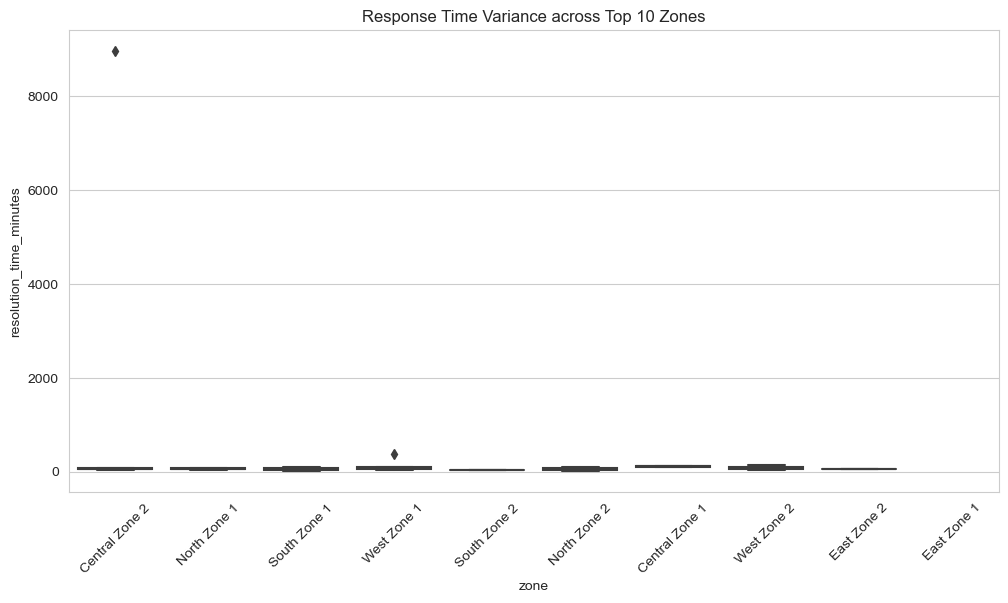

In [11]:
plt.figure(figsize=(12, 6))
top_zones = df['zone'].value_counts().head(10).index
sns.boxplot(x='zone', y=RESPONSE_TIME_TARGET, data=df[df['zone'].isin(top_zones)])
plt.title("Response Time Variance across Top 10 Zones")
plt.xticks(rotation=45)
plt.show()

## 4. Geospatial Heatmap (Operational Hotspots)

In [13]:
pip install folium

  Obtaining dependency information for folium from https://files.pythonhosted.org/packages/b5/a8/5f764f333204db0390362a4356d03a43626997f26818a0e9396f1b3bd8c9/folium-0.20.0-py2.py3-none-any.whl.metadata
  Obtaining dependency information for branca>=0.6.0 from https://files.pythonhosted.org/packages/7e/50/fc9680058e63161f2f63165b84c957a0df1415431104c408e8104a3a18ef/branca-0.8.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/113.4 kB ? eta -:--:--
   --- ------------------------------------ 10.2/113.4 kB ? eta -:--:--
   ---------------------------- ---------- 81.9/113.4 kB 919.0 kB/s eta 0:00:01
   -------------------------------------- 113.4/113.4 kB 825.2 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [14]:
import folium
from folium.plugins import HeatMap

# Filter valid coordinates just in case
geo_df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]
center_lat = geo_df['latitude'].median()
center_lon = geo_df['longitude'].median()

m = folium.Map(location=[center_lat, center_lon], zoom_start=11)
heat_data = [[row['latitude'], row['longitude'], row[CONGESTION_TARGET]] 
             for index, row in geo_df.dropna(subset=['latitude', 'longitude']).iterrows()]
HeatMap(heat_data, radius=10, blur=15).add_to(m)

# Display map (Will render in VS Code Jupyter)
m